In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
dt = '2026-02-06'
ohlcv_1m = pd.read_parquet(f'data/raw/amberdata/market_data/spot/ohlcv_1m/binance/{dt}/eth_usdt.parquet')

In [12]:
def load_data(dt):
    ohlcv_1m = pd.read_parquet(f'data/raw/amberdata/market_data/spot/ohlcv_1m/binance/{dt}/eth_usdt.parquet')
    ohlcv_1m['timestamp'] = pd.to_datetime(ohlcv_1m['exchangeTimestamp'],unit='ms')
    ohlcv_1m['date'] = ohlcv_1m['timestamp'].dt.date
    ohlcv_1m['time'] = ohlcv_1m['timestamp'].dt.time
    return ohlcv_1m

In [14]:
def bulk_load_data(dt_list):
    data = pd.concat([load_data(dt) for dt in dt_list])
    return data

In [15]:
dt_list = pd.date_range(start='2025-01-01', end='2026-01-31').strftime('%Y-%m-%d').tolist()
df = bulk_load_data(dt_list)
df.head()


,exchangeTimestamp,open,high,low,close,volume,timestamp,date,time
0,1735689600000,3337.78,3337.99,3335.84,3337.99,171.7281,2025-01-01 00:00:00,2025-01-01,00:00:00
1,1735689660000,3337.99,3338.86,3337.42,3338.86,69.0122,2025-01-01 00:01:00,2025-01-01,00:01:00
2,1735689720000,3338.86,3342.32,3338.86,3342.32,104.9957,2025-01-01 00:02:00,2025-01-01,00:02:00
3,1735689780000,3342.32,3342.44,3338.96,3339.98,183.7958,2025-01-01 00:03:00,2025-01-01,00:03:00
4,1735689840000,3339.98,3343.02,3339.98,3340.26,177.9110,2025-01-01 00:04:00,2025-01-01,00:04:00


In [240]:
from curses import window


df['dollar_volume'] = df['volume'] * df['close']
df['lag_close'] = df['close'].shift(1)
df['true_range'] = df.apply(
    lambda r: np.max([r['high']-r['low'], abs(r['high']-r['lag_close']), abs(r['low']-r['lag_close'])]),
    axis=1
)
df['true_range_norm_by_volume'] = np.log(df['true_range'] / df['volume'])
df['true_range_norm_by_volume_norm_factor'] = df['true_range_norm_by_volume'].abs().rolling(window=60*24).mean()
df['true_range_norm_by_volume_norm'] = df['true_range_norm_by_volume'] / df['true_range_norm_by_volume_norm_factor']
df['vwap'] = df['dollar_volume'].rolling(window=60*24*5).sum() / df['volume'].rolling(window=60*24*5).sum()
df['vwap_dev'] = np.log(df['close'] / df['vwap'])
df['ret_fwd1'] = np.log(df['close'].shift(-1) / df['close'])
df['ret_fwd2'] = np.log(df['close'].shift(-2) / df['close'])
df['ret_fwd3'] = np.log(df['close'].shift(-3) / df['close'])
df['ret_fwd4'] = np.log(df['close'].shift(-4) / df['close'])
df['ret_fwd5'] = np.log(df['close'].shift(-5) / df['close'])
df['ret_fwd6'] = np.log(df['close'].shift(-6) / df['close'])
df['ret_fwd7'] = np.log(df['close'].shift(-7) / df['close'])
df['ret_fwd8'] = np.log(df['close'].shift(-8) / df['close'])
df['ret_fwd9'] = np.log(df['close'].shift(-9) / df['close'])
df['ret_fwd10'] = np.log(df['close'].shift(-10) / df['close'])
df['ret_fwd11'] = np.log(df['close'].shift(-11) / df['close'])
df['ret_fwd12'] = np.log(df['close'].shift(-12) / df['close'])
df['ret_fwd13'] = np.log(df['close'].shift(-13) / df['close'])
df['ret_fwd14'] = np.log(df['close'].shift(-14) / df['close'])
df['ret_fwd15'] = np.log(df['close'].shift(-15) / df['close'])
df['ret_fwd16'] = np.log(df['close'].shift(-16) / df['close'])
df['ret_fwd17'] = np.log(df['close'].shift(-17) / df['close'])
df['ret_fwd18'] = np.log(df['close'].shift(-18) / df['close'])
df['ret_fwd19'] = np.log(df['close'].shift(-19) / df['close'])
df['ret_fwd20'] = np.log(df['close'].shift(-20) / df['close'])


df['vwap_dev_norm_factor'] = df['vwap_dev'].abs().rolling(window=60*24).mean()
df['vwap_dev_norm'] = df['vwap_dev'] / df['vwap_dev_norm_factor']

<Axes: >

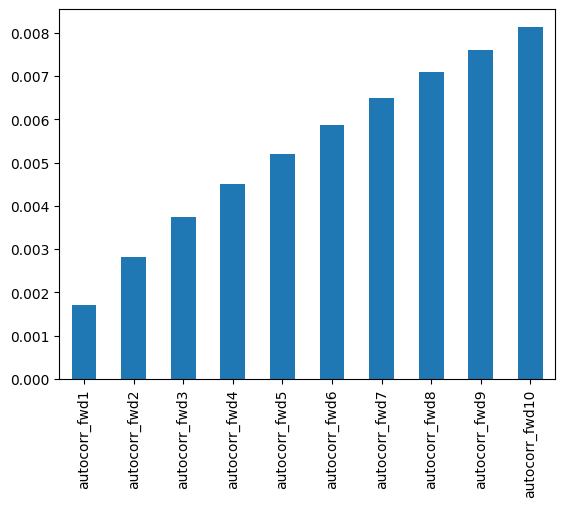

In [241]:
pd.Series({
    'autocorr_fwd1': df['vwap_dev_norm'].corr(df['ret_fwd1']),
    'autocorr_fwd2': df['vwap_dev_norm'].corr(df['ret_fwd2']),
    'autocorr_fwd3': df['vwap_dev_norm'].corr(df['ret_fwd3']),
    'autocorr_fwd4': df['vwap_dev_norm'].corr(df['ret_fwd4']),
    'autocorr_fwd5': df['vwap_dev_norm'].corr(df['ret_fwd5']),
    'autocorr_fwd6': df['vwap_dev_norm'].corr(df['ret_fwd6']),
    'autocorr_fwd7': df['vwap_dev_norm'].corr(df['ret_fwd7']),
    'autocorr_fwd8': df['vwap_dev_norm'].corr(df['ret_fwd8']),
    'autocorr_fwd9': df['vwap_dev_norm'].corr(df['ret_fwd9']),
    'autocorr_fwd10': df['vwap_dev_norm'].corr(df['ret_fwd10']),
}).plot(kind='bar')



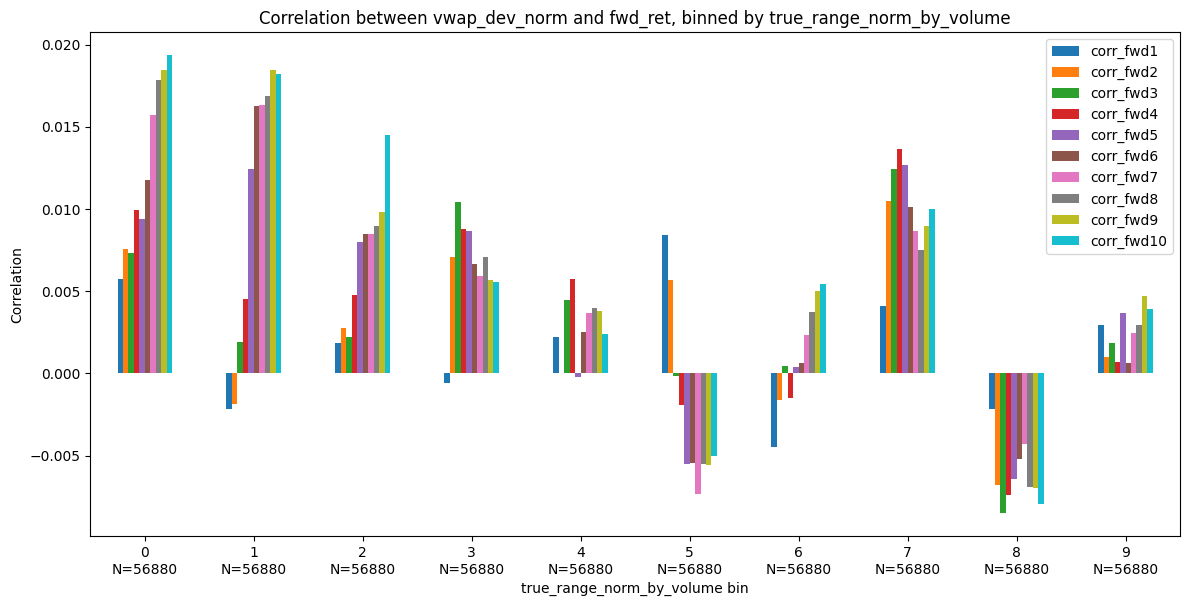

In [242]:
# Calculate the correlation between vwap_dev_norm and each fwd_ret, but within bins of true_range_norm_by_volume

num_bins = 10
# Bin the true_range_norm_by_volume column using quantiles for more even bin sizes
df['trnbv_bin'] = pd.qcut(df['true_range_norm_by_volume_norm'], num_bins, labels=False, duplicates='drop')
#df['trnbv_bin'] = pd.cut(df['true_range_norm_by_volume'], num_bins, labels=False, duplicates='drop')

corrs = []
for bin_id, group in df.groupby('trnbv_bin'):
    entry = {
        'bin': bin_id,
        'corr_fwd1': group['vwap_dev_norm'].corr(group['ret_fwd1']),
        'corr_fwd2': group['vwap_dev_norm'].corr(group['ret_fwd2']),
        'corr_fwd3': group['vwap_dev_norm'].corr(group['ret_fwd3']),
        'corr_fwd4': group['vwap_dev_norm'].corr(group['ret_fwd4']),
        'corr_fwd5': group['vwap_dev_norm'].corr(group['ret_fwd5']),
        'corr_fwd6': group['vwap_dev_norm'].corr(group['ret_fwd6']),
        'corr_fwd7': group['vwap_dev_norm'].corr(group['ret_fwd7']),
        'corr_fwd8': group['vwap_dev_norm'].corr(group['ret_fwd8']),
        'corr_fwd9': group['vwap_dev_norm'].corr(group['ret_fwd9']),
        'corr_fwd10': group['vwap_dev_norm'].corr(group['ret_fwd10']),
    }
    corrs.append(entry)

corrs_df = pd.DataFrame(corrs).set_index('bin')


# Add sample size annotations to each bin in the bar plot

# Get bin counts from the original binning
bin_counts = df['trnbv_bin'].value_counts().sort_index()

# Plot as before
ax = corrs_df.plot(kind='bar', figsize=(12, 6))
plt.ylabel('Correlation')
plt.title('Correlation between vwap_dev_norm and fwd_ret, binned by true_range_norm_by_volume')
plt.xlabel('true_range_norm_by_volume bin')
plt.xticks(rotation=0)
plt.tight_layout()

# Annotate sample sizes on x-axis labels, handling possible float/integer label values robustly
new_labels = []
for label in ax.get_xticklabels():
    label_text = label.get_text()
    try:
        # Attempt to parse as float and then int, for cases like '0.0'
        bin_number = int(float(label_text))
    except (ValueError, TypeError):
        # If cannot parse, leave as is (fallback) with empty count
        bin_number = label_text
    count = bin_counts.get(bin_number, 0)
    new_labels.append(f'{bin_number}\nN={count}')
ax.set_xticklabels(new_labels)

plt.show()

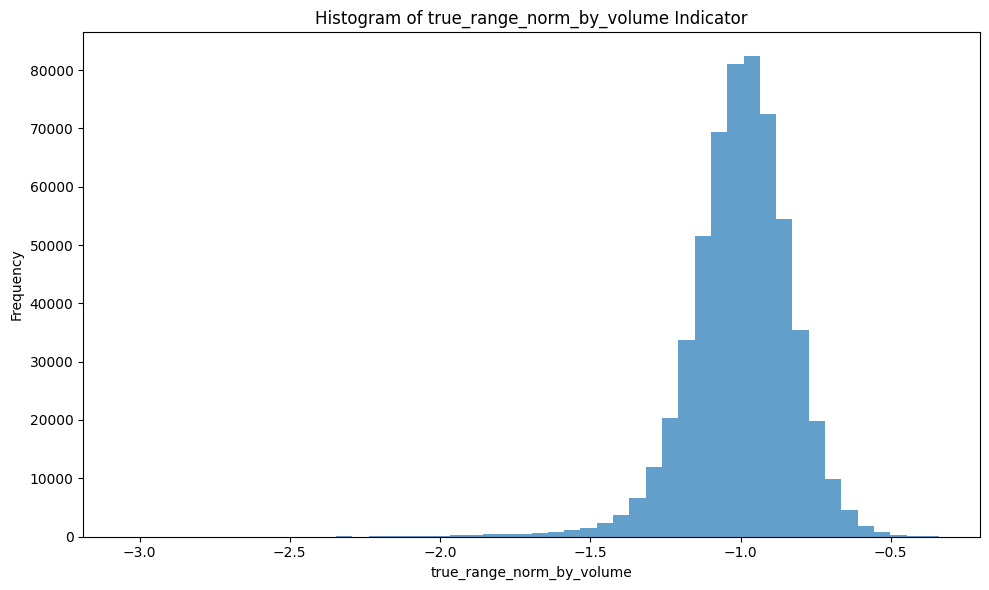

In [243]:
plt.figure(figsize=(10, 6))
plt.hist(df['true_range_norm_by_volume_norm'].dropna(), bins=50, alpha=0.7)
plt.xlabel('true_range_norm_by_volume')
plt.ylabel('Frequency')
plt.title('Histogram of true_range_norm_by_volume Indicator')
plt.tight_layout()
plt.show()

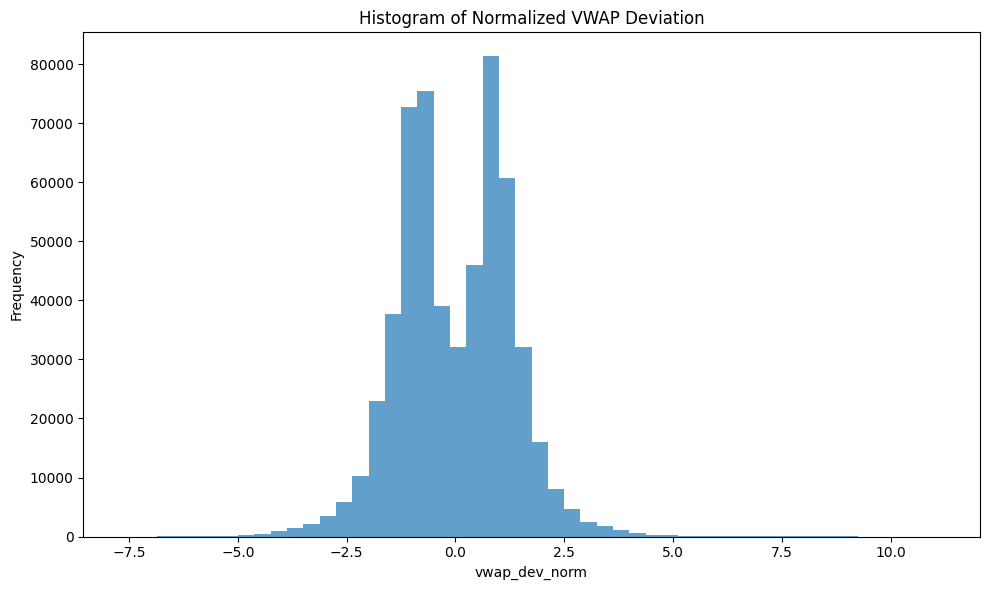

In [244]:
plt.figure(figsize=(10, 6))
plt.hist(df['vwap_dev_norm'].dropna(), bins=50, alpha=0.7)
plt.xlabel('vwap_dev_norm')
plt.ylabel('Frequency')
plt.title('Histogram of Normalized VWAP Deviation')
plt.tight_layout()
plt.show()

In [245]:
# Consolidate backtest dataframe with desired columns and correct column names
backtest_df = df.loc[:, [
    'timestamp',
    'close',
    'vwap_dev_norm',
    'true_range_norm_by_volume_norm',
    'ret_fwd1', 'ret_fwd2', 'ret_fwd3', 'ret_fwd4', 'ret_fwd5',
    'ret_fwd6', 'ret_fwd7', 'ret_fwd8', 'ret_fwd9', 'ret_fwd10',
    'ret_fwd11', 'ret_fwd12', 'ret_fwd13', 'ret_fwd14', 'ret_fwd15',
    'ret_fwd16', 'ret_fwd17', 'ret_fwd18', 'ret_fwd19', 'ret_fwd20'
]].copy().dropna()

# Optional: display a preview for verification
display(backtest_df.head())

,timestamp,close,vwap_dev_norm,true_range_norm_by_volume_norm,ret_fwd1,ret_fwd2,ret_fwd3,ret_fwd4,ret_fwd5,ret_fwd6,...,ret_fwd11,ret_fwd12,ret_fwd13,ret_fwd14,ret_fwd15,ret_fwd16,ret_fwd17,ret_fwd18,ret_fwd19,ret_fwd20
1438,2025-01-06 23:58:00,3687.73,0.915085,-0.804919,-0.000076,-0.001134,-0.001579,-0.001968,-0.002112,-0.002449,...,-0.003300,-0.003262,-0.002811,-0.003001,-0.003009,-0.002775,-0.003287,-0.003409,-0.002724,-0.001574
1439,2025-01-06 23:59:00,3687.45,0.912918,-1.293869,-0.001058,-0.001504,-0.001892,-0.002036,-0.002373,-0.002436,...,-0.003186,-0.002735,-0.002925,-0.002933,-0.002699,-0.003211,-0.003333,-0.002648,-0.001498,-0.000958
0,2025-01-07 00:00:00,3683.55,0.882136,-1.160923,-0.000445,-0.000834,-0.000978,-0.001315,-0.001377,-0.001897,...,-0.001676,-0.001867,-0.001875,-0.001641,-0.002152,-0.002275,-0.001589,-0.000440,0.000100,-0.000079
1,2025-01-07 00:01:00,3681.91,0.869174,-1.069363,-0.000388,-0.000532,-0.000869,-0.000932,-0.001451,-0.001683,...,-0.001421,-0.001430,-0.001196,-0.001707,-0.001830,-0.001144,0.000005,0.000546,0.000367,0.000771
2,2025-01-07 00:02:00,3680.48,0.858115,-1.149293,-0.000144,-0.000481,-0.000544,-0.001063,-0.001294,-0.001509,...,-0.001041,-0.000807,-0.001319,-0.001441,-0.000756,0.000394,0.000934,0.000755,0.001160,0.001865


In [246]:
import numpy as np

# Adjust the take profit threshold
tp = 0.005   # 30bps = 0.30%
sl = -0.005  # -10bps = -0.10%

# Columns for forward returns (already present in backtest_df)
ret_cols = [f'ret_fwd{i}' for i in range(1, 21)]

def check_tp_sl(row):
    rets = row[ret_cols].values
    tp_hit = np.where(rets >= tp)[0]
    sl_hit = np.where(rets <= sl)[0]
    
    # Find which comes first
    first_tp = tp_hit[0] if len(tp_hit) > 0 else np.inf
    first_sl = sl_hit[0] if len(sl_hit) > 0 else np.inf

    if first_tp < first_sl:
        # TP hit first
        return 'TP', rets[first_tp]
    elif first_sl < first_tp:
        # SL hit first
        return 'SL', rets[first_sl]
    else:
        # Neither hit: take final available return
        return 'NONE', rets[-1]

# Apply function row-wise to determine outcome and PnL
tp_sl_res = backtest_df.apply(lambda row: check_tp_sl(row), axis=1)
backtest_df['tp_sl'] = tp_sl_res.apply(lambda x: x[0])
backtest_df['pnl'] = tp_sl_res.apply(lambda x: x[1])

# Optional: display new columns for verification
display(backtest_df[['timestamp', 'tp_sl', 'pnl']].head())

,timestamp,tp_sl,pnl
1438,2025-01-06 23:58:00,NONE,-0.001574
1439,2025-01-06 23:59:00,NONE,-0.000958
0,2025-01-07 00:00:00,NONE,-0.000079
1,2025-01-07 00:01:00,NONE,0.000771
2,2025-01-07 00:02:00,NONE,0.001865


In [276]:
# Entry rule columns:

# 1. vwap_dev_norm entry signals: > 1.5 -> short; < -1.5 -> long
backtest_df['entry_vwap_dev'] = np.where(
    backtest_df['vwap_dev_norm'] > 1.5, 'short',
    np.where(backtest_df['vwap_dev_norm'] < -1.5, 'long', 'none')
)

# 2. true_range_norm_by_volume_norm filters (reversion/trend regime):
#    > -1: revert; <= -1: trend
backtest_df['entry_tr_volregime'] = np.where(
    backtest_df['true_range_norm_by_volume_norm'] > -1, 'revert', 'trend'
)

# Optional: show
display(backtest_df[['timestamp', 'entry_vwap_dev', 'entry_tr_volregime']].head())

,timestamp,entry_vwap_dev,entry_tr_volregime
1438,2025-01-06 23:58:00,none,revert
1439,2025-01-06 23:59:00,none,trend
0,2025-01-07 00:00:00,none,trend
1,2025-01-07 00:01:00,none,trend
2,2025-01-07 00:02:00,none,trend


In [277]:
# Given tp=30bps (0.003), sl=10bps (0.001), recompute TRUE tp/sl logic based on *true* trade direction (entry_vwap_dev)

tp_true = 0.005   # 30 bps
sl_true = -0.001  # -10 bps

# Find all ret_fwd columns
ret_fwd_cols = [col for col in backtest_df.columns if col.startswith('ret_fwd')]

def tpsl_true_row(row):
    entry = row['entry_vwap_dev']
    if entry == 'long':
        # Use forward returns as-is
        fwd_rets = row[ret_fwd_cols].values
        tp_hit = np.where(fwd_rets >= tp_true)[0]
        sl_hit = np.where(fwd_rets <= sl_true)[0]
        first_tp = tp_hit[0] if len(tp_hit) > 0 else np.inf
        first_sl = sl_hit[0] if len(sl_hit) > 0 else np.inf
        if first_tp < first_sl:
            return 'TP', fwd_rets[first_tp]
        elif first_sl < first_tp:
            return 'SL', fwd_rets[first_sl]
        else:
            return 'NONE', fwd_rets[-1]
    elif entry == 'short':
        # For shorts, invert the returns (profit if price falls)
        fwd_rets = -row[ret_fwd_cols].values
        tp_hit = np.where(fwd_rets >= tp_true)[0]   # price moved down 30bps
        sl_hit = np.where(fwd_rets <= sl_true)[0]   # price moved up 10bps
        first_tp = tp_hit[0] if len(tp_hit) > 0 else np.inf
        first_sl = sl_hit[0] if len(sl_hit) > 0 else np.inf
        if first_tp < first_sl:
            return 'TP', -row[ret_fwd_cols].values[first_tp]
        elif first_sl < first_tp:
            return 'SL', -row[ret_fwd_cols].values[first_sl]
        else:
            # No TP/SL hit; final return as PnL (sign adjusted)
            return 'NONE', -row[ret_fwd_cols].values[-1]
    else:
        # entry == 'none': no trade
        return 'NONE', 0.0

true_res = backtest_df.apply(tpsl_true_row, axis=1)
backtest_df['true_stop'] = true_res.apply(lambda x: x[0])
backtest_df['true_pnl'] = true_res.apply(lambda x: x[1])
backtest_df['true_position'] = backtest_df['entry_vwap_dev']

backtest_df.head()

,timestamp,close,vwap_dev_norm,true_range_norm_by_volume_norm,ret_fwd1,ret_fwd2,ret_fwd3,ret_fwd4,ret_fwd5,ret_fwd6,...,ret_fwd19,ret_fwd20,tp_sl,pnl,entry_vwap_dev,entry_tr_volregime,true_stop,true_pnl,true_position,true_range_bin
1438,2025-01-06 23:58:00,3687.73,0.915085,-0.804919,-0.000076,-0.001134,-0.001579,-0.001968,-0.002112,-0.002449,...,-0.002724,-0.001574,NONE,-0.001574,none,revert,NONE,0.0,none,9
1439,2025-01-06 23:59:00,3687.45,0.912918,-1.293869,-0.001058,-0.001504,-0.001892,-0.002036,-0.002373,-0.002436,...,-0.001498,-0.000958,NONE,-0.000958,none,trend,NONE,0.0,none,0
0,2025-01-07 00:00:00,3683.55,0.882136,-1.160923,-0.000445,-0.000834,-0.000978,-0.001315,-0.001377,-0.001897,...,0.000100,-0.000079,NONE,-0.000079,none,trend,NONE,0.0,none,1
1,2025-01-07 00:01:00,3681.91,0.869174,-1.069363,-0.000388,-0.000532,-0.000869,-0.000932,-0.001451,-0.001683,...,0.000367,0.000771,NONE,0.000771,none,trend,NONE,0.0,none,3
2,2025-01-07 00:02:00,3680.48,0.858115,-1.149293,-0.000144,-0.000481,-0.000544,-0.001063,-0.001294,-0.001509,...,0.001160,0.001865,NONE,0.001865,none,trend,NONE,0.0,none,1


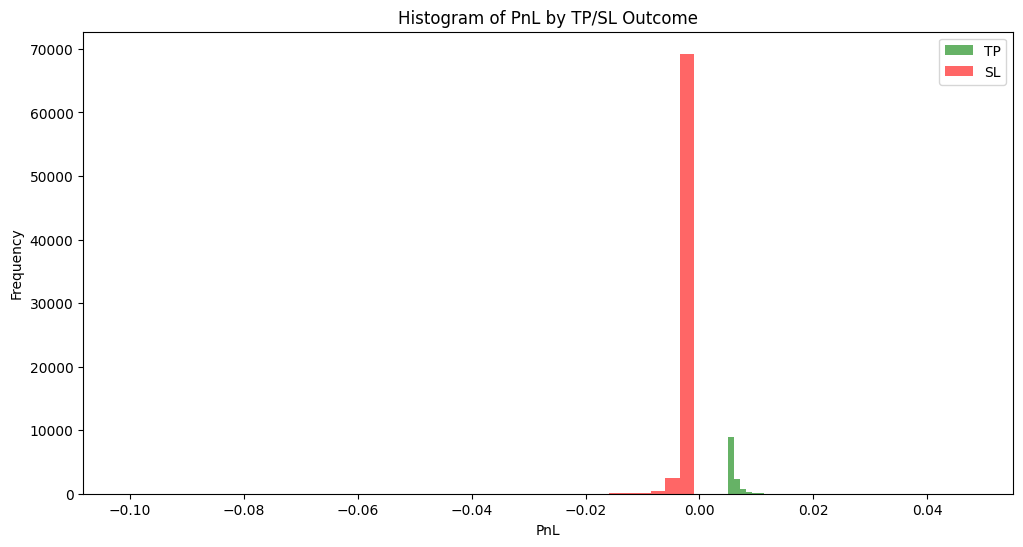

In [278]:
import matplotlib.pyplot as plt

# Plot histogram of PnL for only TP and SL outcomes
plt.figure(figsize=(12, 6))
outcomes = ['TP', 'SL']
colors = {'TP': 'green', 'SL': 'red'}

for outcome in outcomes:
    pnl_data = backtest_df.loc[backtest_df['true_stop'] == outcome, 'true_pnl']
    plt.hist(pnl_data, bins=40, alpha=0.6, label=outcome, color=colors[outcome])

plt.title("Histogram of PnL by TP/SL Outcome")
plt.xlabel("PnL")
plt.ylabel("Frequency")
plt.legend()
plt.show()

In [279]:
# Show dataframe without the ret_fwd columns
cols_to_exclude = [col for col in backtest_df.columns if col.startswith('ret_fwd')]
df_without_ret_fwd = backtest_df.drop(columns=cols_to_exclude)
display(df_without_ret_fwd.head())

,timestamp,close,vwap_dev_norm,true_range_norm_by_volume_norm,tp_sl,pnl,entry_vwap_dev,entry_tr_volregime,true_stop,true_pnl,true_position,true_range_bin
1438,2025-01-06 23:58:00,3687.73,0.915085,-0.804919,NONE,-0.001574,none,revert,NONE,0.0,none,9
1439,2025-01-06 23:59:00,3687.45,0.912918,-1.293869,NONE,-0.000958,none,trend,NONE,0.0,none,0
0,2025-01-07 00:00:00,3683.55,0.882136,-1.160923,NONE,-0.000079,none,trend,NONE,0.0,none,1
1,2025-01-07 00:01:00,3681.91,0.869174,-1.069363,NONE,0.000771,none,trend,NONE,0.0,none,3
2,2025-01-07 00:02:00,3680.48,0.858115,-1.149293,NONE,0.001865,none,trend,NONE,0.0,none,1


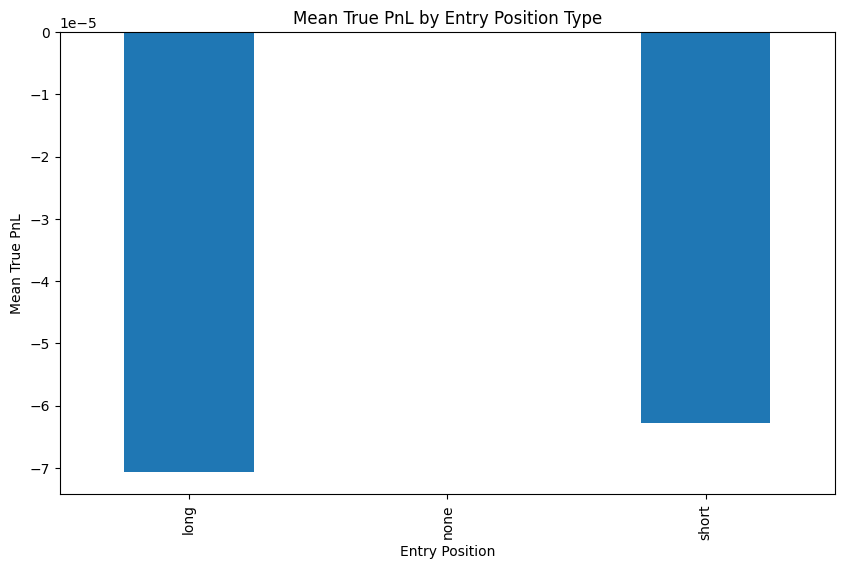

In [280]:
import matplotlib.pyplot as plt

# Group by position type ('short', 'long', 'none') and plot the mean of true_pnl
mean_true_pnl = backtest_df.groupby('entry_vwap_dev')['true_pnl'].mean()

plt.figure(figsize=(10, 6))
mean_true_pnl.plot(kind='bar')
plt.title('Mean True PnL by Entry Position Type')
plt.xlabel('Entry Position')
plt.ylabel('Mean True PnL')
plt.show()

In [281]:
# Bin true_range readings into 5 quantiles (very low, low, medium, high, very high volatility)
true_range_bins = pd.qcut(
    backtest_df['true_range_norm_by_volume_norm'],
    q=10,
    labels=False
)
backtest_df['true_range_bin'] = true_range_bins

backtest_df.head()

,timestamp,close,vwap_dev_norm,true_range_norm_by_volume_norm,ret_fwd1,ret_fwd2,ret_fwd3,ret_fwd4,ret_fwd5,ret_fwd6,...,ret_fwd19,ret_fwd20,tp_sl,pnl,entry_vwap_dev,entry_tr_volregime,true_stop,true_pnl,true_position,true_range_bin
1438,2025-01-06 23:58:00,3687.73,0.915085,-0.804919,-0.000076,-0.001134,-0.001579,-0.001968,-0.002112,-0.002449,...,-0.002724,-0.001574,NONE,-0.001574,none,revert,NONE,0.0,none,9
1439,2025-01-06 23:59:00,3687.45,0.912918,-1.293869,-0.001058,-0.001504,-0.001892,-0.002036,-0.002373,-0.002436,...,-0.001498,-0.000958,NONE,-0.000958,none,trend,NONE,0.0,none,0
0,2025-01-07 00:00:00,3683.55,0.882136,-1.160923,-0.000445,-0.000834,-0.000978,-0.001315,-0.001377,-0.001897,...,0.000100,-0.000079,NONE,-0.000079,none,trend,NONE,0.0,none,1
1,2025-01-07 00:01:00,3681.91,0.869174,-1.069363,-0.000388,-0.000532,-0.000869,-0.000932,-0.001451,-0.001683,...,0.000367,0.000771,NONE,0.000771,none,trend,NONE,0.0,none,3
2,2025-01-07 00:02:00,3680.48,0.858115,-1.149293,-0.000144,-0.000481,-0.000544,-0.001063,-0.001294,-0.001509,...,0.001160,0.001865,NONE,0.001865,none,trend,NONE,0.0,none,1


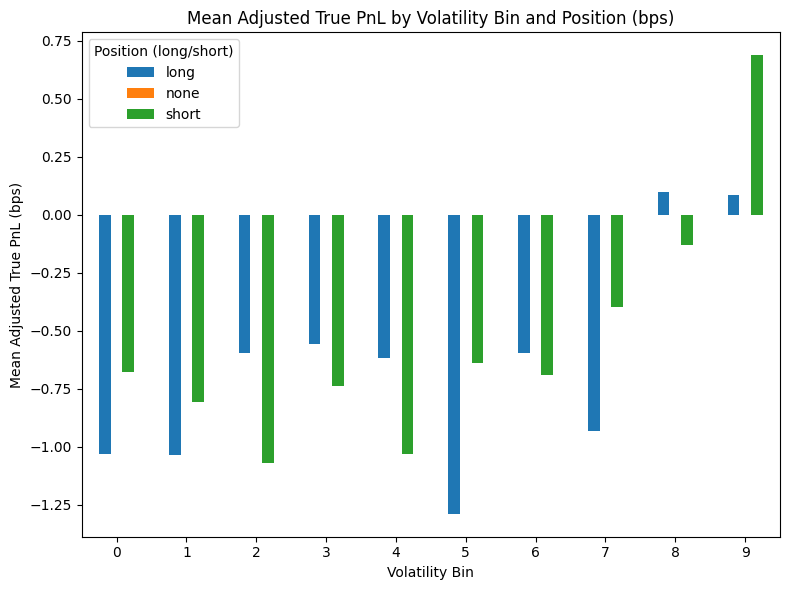

In [282]:
# Group by true_range_bin (volatility level) and adj_true_position (long/short), calculate mean adjusted pnl in bps
grouped = backtest_df.groupby(['true_range_bin', 'true_position'])['true_pnl'].mean().unstack()

# Convert mean PnL to basis points (bps)
grouped_bps = grouped * 10000

# Plot the grouped mean in bps
ax = grouped_bps.plot(kind='bar', figsize=(8,6))
plt.title("Mean Adjusted True PnL by Volatility Bin and Position (bps)")
plt.ylabel("Mean Adjusted True PnL (bps)")
plt.xlabel("Volatility Bin")
plt.xticks(rotation=0)
plt.legend(title="Position (long/short)")
plt.tight_layout()
plt.show()

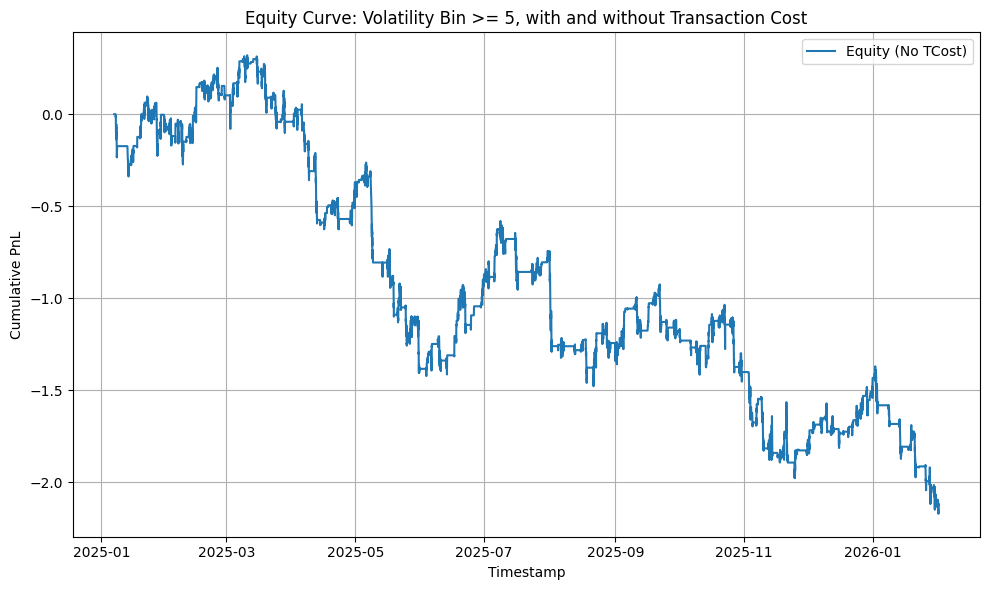

In [283]:
# Plot the equity curve (cumulative sum of true_pnl) when taking positions only if volatility bin >= 5
mask = backtest_df['true_range_bin'] >= 5
filtered_df = backtest_df[mask].copy()

# Standard equity curve (no transaction cost)
equity_curve = filtered_df['true_pnl'].cumsum()

# Equity curve with transaction cost: subtract 10bps per trade
TCOST_BPS = 0.001  # 10bps = 0.001 in pnl units (assuming true_pnl is not in bps)
# Mark a trade whenever position changes, i.e., "adj_true_position" changes compared to previous row, or if it's a new position (not 'none')
# We'll register tcost when adj_true_position switches from 'none' to something else (entry), or changes direction.
trades = (filtered_df['true_position'] != filtered_df['true_position'].shift(1)) & (filtered_df['true_position'] != 'none')
# We also want to penalize for entry, not for flat periods.
tcosts = trades.astype(float) * TCOST_BPS
equity_curve_tcost = (filtered_df['true_pnl'] - tcosts).cumsum()

plt.figure(figsize=(10, 6))
plt.plot(filtered_df['timestamp'], equity_curve, label='Equity (No TCost)')
#plt.plot(filtered_df['timestamp'], equity_curve_tcost, linestyle=':', label='Equity (10bps TCost)', color='red')
plt.title('Equity Curve: Volatility Bin >= 5, with and without Transaction Cost')
plt.xlabel('Timestamp')
plt.ylabel('Cumulative PnL')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

<Axes: xlabel='time'>

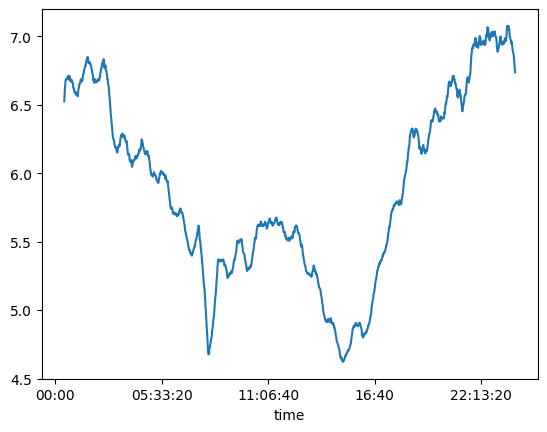

In [52]:
s1 = df.groupby('time')['true_range_norm_by_volume'].sum()#.plot()

s1.rolling(window=30).mean().plot()

<Axes: xlabel='time'>

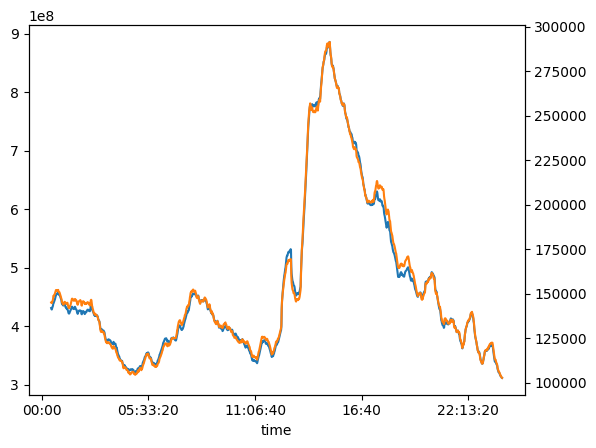

In [50]:
s1 = df.groupby('time')['dollar_volume'].sum()#.plot()
s2 = df.groupby('time')['true_range'].sum()#.plot(secondary_y=True)
s3 = df.groupby('time')['volume'].sum()

s1.rolling(window=30).mean().plot()
#s2.rolling(window=30).mean().plot(secondary_y=True)
s3.rolling(window=30).mean().plot(secondary_y=True)

<Axes: >

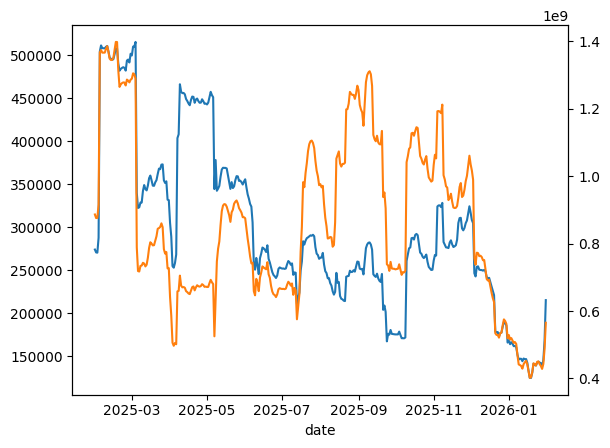

In [26]:

s1.rolling(window=30).std().plot()
s2.rolling(window=30).std().plot(secondary_y=True)

In [24]:
from statsmodels.tsa.stattools import adfuller, kpss

def adf_test(x):
    res = adfuller(x.dropna())
    return {"stat": res[0], "p": res[1]}

def kpss_test(x):
    res = kpss(x.dropna(), regression="c", nlags="auto")
    return {"stat": res[0], "p": res[1]}

s1_adf = adf_test(df["s1"])
s2_adf = adf_test(df["s2"])
s1_kpss = kpss_test(df["s1"])
s2_kpss = kpss_test(df["s2"])

print("s1 ADF:", s1_adf, "s2 ADF:", s2_adf)
print("s1 KPSS:", s1_kpss, "s2 KPSS:", s2_kpss)

KeyError: 's1'

<Axes: title={'center': 'dollar_volume'}, xlabel='date'>

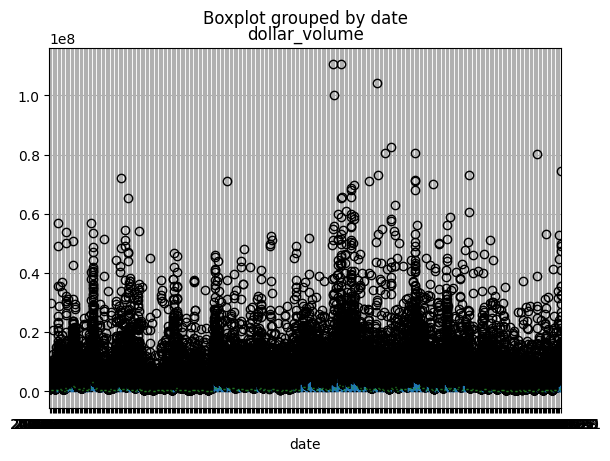

In [17]:
df.boxplot(column='dollar_volume', by='date')
#why so many dots here?